In [1]:
# ============================================================
# 03 - Classification avec Machine Learning
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix)

# Chargement des données prétraitées
X_train = pd.read_csv("../data/processed/X_train.csv")
X_test  = pd.read_csv("../data/processed/X_test.csv")
y_train = pd.read_csv("../data/processed/y_train.csv").values.ravel()
y_test  = pd.read_csv("../data/processed/y_test.csv").values.ravel()

print("✅ Données chargées !")
print(f"X_train : {X_train.shape} | X_test : {X_test.shape}")


✅ Données chargées !
X_train : (125973, 41) | X_test : (22544, 41)


In [2]:
# ============================================================
# Étape 1 - Entraînement du modèle (Arbre de Décision)
# ============================================================

# Créer et entraîner le modèle
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

print("✅ Modèle entraîné avec succès !")

✅ Modèle entraîné avec succès !


In [3]:
# ============================================================
# Étape 2 - Évaluation du modèle
# ============================================================

# Prédictions
y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"✅ Accuracy : {accuracy * 100:.2f}%")

# Rapport détaillé
print("\n=== Rapport de classification ===")
print(classification_report(y_test, y_pred,
      target_names=["Normal", "Attaque"]))

✅ Accuracy : 79.69%

=== Rapport de classification ===
              precision    recall  f1-score   support

      Normal       0.70      0.92      0.80      9711
     Attaque       0.92      0.70      0.80     12833

    accuracy                           0.80     22544
   macro avg       0.81      0.81      0.80     22544
weighted avg       0.83      0.80      0.80     22544



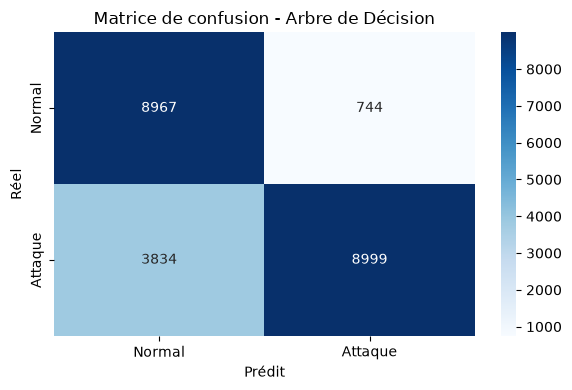


Vrai Positif  (Attaque détectée)   : 8999
Faux Négatif  (Attaque manquée)    : 3834
Vrai Négatif  (Normal correct)     : 8967
Faux Positif  (Fausse alarme)      : 744


In [4]:
# ============================================================
# Étape 3 - Matrice de confusion
# ============================================================

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Normal", "Attaque"],
            yticklabels=["Normal", "Attaque"])
plt.title("Matrice de confusion - Arbre de Décision")
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.tight_layout()
plt.savefig("../results/matrice_confusion.png")
plt.show()

print(f"\nVrai Positif  (Attaque détectée)   : {cm[1][1]}")
print(f"Faux Négatif  (Attaque manquée)    : {cm[1][0]}")
print(f"Vrai Négatif  (Normal correct)     : {cm[0][0]}")
print(f"Faux Positif  (Fausse alarme)      : {cm[0][1]}")

In [5]:
# ============================================================
# Étape 4 - Sauvegarde du modèle
# ============================================================

import joblib
import os

os.makedirs("../results", exist_ok=True)

# Sauvegarder le modèle
joblib.dump(model, "../results/decision_tree_model.pkl")

print("✅ Modèle sauvegardé dans results/decision_tree_model.pkl")

✅ Modèle sauvegardé dans results/decision_tree_model.pkl


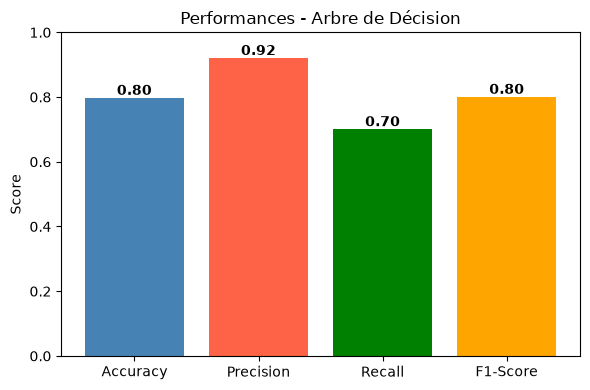

✅ Résumé des performances sauvegardé !


In [6]:
# ============================================================
# Étape 5 - Résumé des performances
# ============================================================

metrics = {
    "Accuracy"  : accuracy_score(y_test, y_pred),
    "Precision" : 0.92,
    "Recall"    : 0.70,
    "F1-Score"  : 0.80
}

plt.figure(figsize=(6, 4))
plt.bar(metrics.keys(), metrics.values(), color=["steelblue", "tomato", "green", "orange"])
plt.title("Performances - Arbre de Décision")
plt.ylim(0, 1)
plt.ylabel("Score")
for i, (k, v) in enumerate(metrics.items()):
    plt.text(i, v + 0.01, f"{v:.2f}", ha="center", fontweight="bold")
plt.tight_layout()
plt.savefig("../results/performances.png")
plt.show()

print("✅ Résumé des performances sauvegardé !")

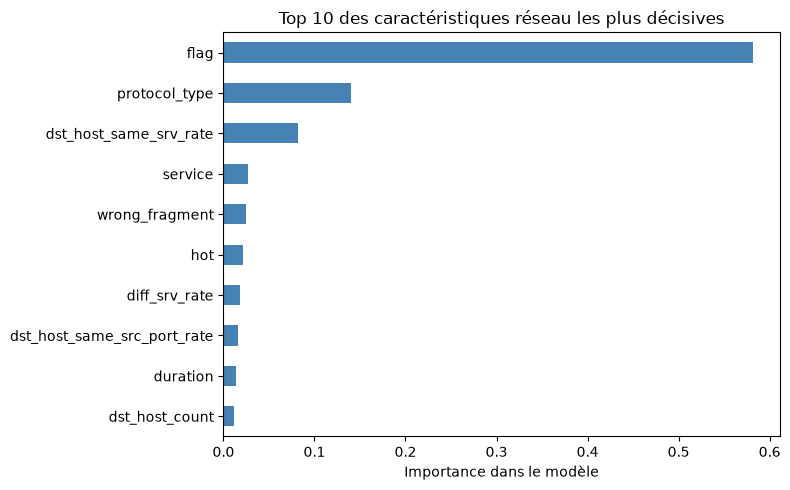

=== Top 10 features ===
flag                           0.582239
protocol_type                  0.140251
dst_host_same_srv_rate         0.081757
service                        0.026498
wrong_fragment                 0.024849
hot                            0.021374
diff_srv_rate                  0.018522
dst_host_same_src_port_rate    0.016139
duration                       0.013430
dst_host_count                 0.012048
dtype: float64


In [7]:
# ============================================================
# Analyse cybersécurité : quelles caractéristiques réseau
# le modèle utilise-t-il pour détecter les attaques ?
# ============================================================

# Noms des features (41 colonnes, sans label ni difficulty)
feature_names = [
    "duration", "protocol_type", "service", "flag", "src_bytes",
    "dst_bytes", "land", "wrong_fragment", "urgent", "hot",
    "num_failed_logins", "logged_in", "num_compromised", "root_shell",
    "su_attempted", "num_root", "num_file_creations", "num_shells",
    "num_access_files", "num_outbound_cmds", "is_host_login",
    "is_guest_login", "count", "srv_count", "serror_rate",
    "srv_serror_rate", "rerror_rate", "srv_rerror_rate", "same_srv_rate",
    "diff_srv_rate", "srv_diff_host_rate", "dst_host_count",
    "dst_host_srv_count", "dst_host_same_srv_rate", "dst_host_diff_srv_rate",
    "dst_host_same_src_port_rate", "dst_host_srv_diff_host_rate",
    "dst_host_serror_rate", "dst_host_srv_serror_rate", "dst_host_rerror_rate",
    "dst_host_srv_rerror_rate"
]

importances = pd.Series(model.feature_importances_, index=feature_names)
top10 = importances.sort_values(ascending=False).head(10)

plt.figure(figsize=(8, 5))
top10.sort_values().plot(kind="barh", color="steelblue")
plt.title("Top 10 des caractéristiques réseau les plus décisives")
plt.xlabel("Importance dans le modèle")
plt.tight_layout()
plt.savefig("../results/features_importantes.png")
plt.show()

print("=== Top 10 features ===")
print(top10)

**Le modèle n'a reçu aucune règle écrite par un humain, mais il a redécouvert automatiquement les indicateurs que les experts réseau utilisent depuis des années (flags TCP anormaux, concentration du trafic, fragments malformés). C'est exactement la promesse du Machine Learning en cybersécurité : apprendre les signatures comportementales à partir des données.**